In [7]:
# Visualization
import matplotlib.pyplot as plt
#import seaborn as sns

# Data Science
import numpy as np
import pandas as pd

# Feature Engineering
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow import keras
#import tf_keras as keras  # Use tf_keras instead of tf.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
import tensorflow_probability as tfp
import tensorflow_probability.python.layers as tfpl
tfd = tfp.distributions
tfb = tfp.bijectors
from tf_keras.callbacks import CSVLogger

# Planetary Computer Tools
#import pystac_client
#import planetary_computer as pc
#from pystac.extensions.eo import EOExtension as eo

# Others
import os
from tqdm import tqdm

In [8]:
data = pd.read_csv("Data/complete_uhi_satellite_data_20250504_225131.csv")
print(data.columns)
print(data["UHI Index_features"]) 


data[5:]

Index(['Longitude_features', 'Latitude_features', 'datetime_features',
       'UHI Index_features', 'original_index', 'B01', 'B02', 'B03', 'B04',
       'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12', 'ndwi', 'ndvi', 'ndbi',
       'B01 (pooled)', 'B02 (pooled)', 'B03 (pooled)', 'B04 (pooled)',
       'B05 (pooled)', 'B06 (pooled)', 'B07 (pooled)', 'B08 (pooled)',
       'B8A (pooled)', 'B11 (pooled)', 'B12 (pooled)', 'ndwi (pooled)',
       'ndvi (pooled)', 'ndbi (pooled)', 'uhi_id', 'Longitude_tree',
       'Latitude_tree', 'datetime_tree', 'geometry', 'building_count_0-25ft',
       'building_impact_0-25ft', 'building_count_25-50ft',
       'building_impact_25-50ft', 'building_count_50-100ft',
       'building_impact_50-100ft', 'building_count_100-200ft',
       'building_impact_100-200ft', 'building_count_200-500ft',
       'building_impact_200-500ft', 'closest_building_distance',
       'closest_building_height', 'closest_building_area', 'tree_count_0-25ft',
       'tree_impact_0

,Longitude_features,Latitude_features,datetime_features,UHI Index_features,original_index,B01,B02,B03,B04,B05,...,B11_ring1_std,B12_ring1_mean,B12_ring1_std,ndvi_ring1_mean,ndvi_ring1_std,ndbi_ring1_mean,ndbi_ring1_std,ndwi_ring1_mean,ndwi_ring1_std,join_timestamp
5,-73.909280,40.812777,24-07-2021 15:53,1.021634,5,841.5,659.5,763.0,708.5,1077.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-04 22:51:31
6,-73.909312,40.812710,24-07-2021 15:53,1.015143,6,841.5,551.5,768.5,659.0,1077.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-04 22:51:31
7,-73.909340,40.812643,24-07-2021 15:53,1.015143,7,1177.0,656.0,807.0,814.0,1430.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-04 22:51:31
8,-73.909363,40.812562,24-07-2021 15:53,1.012979,8,1177.0,675.0,816.0,845.0,1430.5,...,774.770017,1903.964679,899.857097,2086.424127,1024.065157,2062.699983,1101.266454,2138.886038,1087.064000,2025-05-04 22:51:31
9,-73.909383,40.812485,24-07-2021 15:53,1.012979,9,1177.0,688.0,866.5,802.0,1425.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-04 22:51:31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11224,-73.957050,40.790333,24-07-2021 15:57,0.972470,11224,462.5,491.0,725.5,501.0,999.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-04 22:51:31
11225,-73.957063,40.790308,24-07-2021 15:57,0.972470,11225,462.5,506.5,741.5,551.5,999.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-04 22:51:31
11226,-73.957093,40.790270,24-07-2021 15:57,0.981124,11226,462.5,506.5,741.5,551.5,999.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-04 22:51:31
11227,-73.957112,40.790253,24-07-2021 15:59,0.981245,11227,462.5,506.5,741.5,551.5,999.0,...,767.147097,1909.801398,901.045265,2097.992779,1030.401935,2075.240898,1107.762003,2152.984351,1095.801481,2025-05-04 22:51:31


In [9]:
n_inputs = 28
features = [
    "building_impact_200-500ft",
    "tree_impact_200-500ft",
    "tree_impact_50-100ft",
    "tree_count_200-500ft",
    "tree_count_100-200ft",
    "closest_tree_dbh",
    "B01",
    "B12",
    "B05",
    "B04",
    "B02",
    "ndwi (pooled)",
    "ndvi (pooled)",
    "ndbi (pooled)",
    "ndwi",
    "ndvi",
    "B01 (pooled)",
    "B04 (pooled)",
    "B02 (pooled)",
    "B03 (pooled)",
    "B05 (pooled)"
]

#names array is not used in this case 

#names = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12", "ndwi", "ndvi", "ndbi", 
  #      "B01 (pooled)", "B02 (pooled)", "B03 (pooled)", "B04 (pooled)", "B05 (pooled)", "B06 (pooled)", "B07 (pooled)", "B08 (pooled)", "B8A (pooled)", "B11 (pooled)", "B12 (pooled)", "ndwi (pooled)", "ndvi (pooled)", "ndbi (pooled)",
  #      "building_count_0-25ft", "building_impact_0-25ft", "building_count_25-50ft", "building_impact_25-50ft", "building_count_50-100ft", "building_impact_50-100ft", "building_count_100-200ft", "building_impact_100-200ft", "building_count_200-500ft", "building_impact_200-500ft",
   #     "tree_count_0-25ft", "tree_impact_0-25ft", "tree_count_25-50ft", "tree_impact_25-50ft", "tree_count_50-100ft", "tree_impact_50-100ft", "tree_count_100-200ft", "tree_impact_100-200ft", "tree_count_200-500ft", "tree_impact_200-500ft"]
test_size = 0.3

model_data = data[features + ['UHI Index_features']]
md_data_std = model_data.apply(lambda x: (x - x.mean()) / x.std(), axis=0) 
md_data_std =md_data_std.apply(lambda x: pd.to_numeric(x, errors = 'coerce'), axis=0) 

X = md_data_std.drop(columns=['UHI Index_features']).values
y = md_data_std['UHI Index_features'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size,random_state=123)
print(X_train.shape) 
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

#X_train

(7860, 21)
(7860,)
(3369, 21)
(3369,)


In [ ]:

#For debuggin NAN values in data tables

print(X.dtype)
print(y.dtype)

# Check for NaNs or Infs
print("NaNs in X:", np.isnan(X).any())
print("Infs in X:", np.isinf(X).any())
print("NaNs in y:", np.isnan(y).any())
print("Infs in y:", np.isinf(y).any())

X_df = pd.DataFrame(X)

# Find all cells with NaN
nan_locations = X_df.isna()

# Print which rows and columns have NaNs
nan_summary = nan_locations.sum(axis=0)
print("NaNs per column:")
print(nan_summary[nan_summary > 0])

# Get all rows with any NaNs
rows_with_nan = X_df[nan_locations.any(axis=1)]
print("Rows with NaNs:")
print(rows_with_nan)

# Drop any rows with NaNs
X_df_clean = X_df.dropna()

# Get valid indices to align y
valid_indices = X_df_clean.index

# Final clean X and y
X = X_df_clean.values.astype(np.float32)
y = y[valid_indices].astype(np.float32)

print("NaNs in X:", np.isnan(X).any())
print("Infs in X:", np.isinf(X).any())
print("NaNs in y:", np.isnan(y).any())
print("Infs in y:", np.isinf(y).any())

float64
float64
NaNs in X: False
Infs in X: False
NaNs in y: False
Infs in y: False
NaNs per column:
Series([], dtype: int64)
Rows with NaNs:
Empty DataFrame
Columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Index: []

[0 rows x 21 columns]
NaNs in X: False
Infs in X: False
NaNs in y: False
Infs in y: False


In [13]:
def test_model(model, X_test, y_test):
    y_pred = model.predict(X_test).flatten()
    y_test_tmp = y_test.flatten()
    print(f"MSE: {mean_squared_error(y_test_tmp, y_pred)}")
    print(f"r2: {r2_score(y_test_tmp, y_pred)}")
    y_lazy_pred = np.mean(y_test_tmp) * np.ones(len(y_test_tmp))
    print(f"Lazy MSE: {mean_squared_error(y_test_tmp, y_lazy_pred)}")
    print(f"Lazy r2: {r2_score(y_test_tmp, y_lazy_pred)}")
    
#X.shape
#X_train.shape



In [14]:
# Standard Model
model1 = Sequential([
    Dense(32, activation = 'relu'       
        ,kernel_regularizer=regularizers.l2(0.001)),

    Dropout(0.1),
    Dense(32, activation = 'relu'
        ,kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.1),
    Dense(1, activation = 'linear'),
])

model1.compile(optimizer=Adam(learning_rate=0.001) , loss = "MSE" )
log = CSVLogger(f"Model_Stats/standard_training.log", append=True)
model1.fit(X_train, y_train, epochs=100, validation_split=0.1, callbacks=[log])

Epoch 1/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1323 - val_loss: 0.9007
Epoch 2/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - loss: 0.8751 - val_loss: 0.8571
Epoch 3/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step - loss: 0.8262 - val_loss: 0.8447
Epoch 4/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8289 - val_loss: 0.8273
Epoch 5/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step - loss: 0.7976 - val_loss: 0.8065
Epoch 6/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7879 - val_loss: 0.7877
Epoch 7/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - loss: 0.7749 - val_loss: 0.7773
Epoch 8/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 943us/step - loss: 0.7564 - val_loss: 0.7594
Epoch 9/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 724us/step - loss: 0.7434 - val_loss: 0.7481
Epoch 10/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step - loss: 0.7371 - val_loss: 0.7384
Epoch 11/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step - loss: 0.7374 - val_loss: 0.7333
Epoch 12/100
222/222 ━━━━

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 472us/step
MSE: 0.4736502006848779
r2: 0.519988663784142
Lazy MSE: 0.9867479472857295
Lazy r2: 0.0


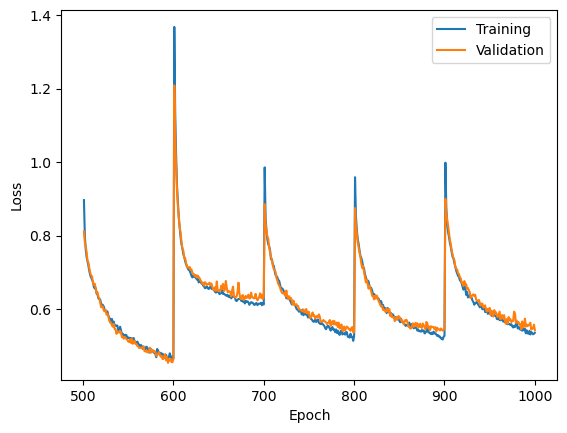

In [15]:
test_model(model1, X_test=X_test, y_test=y_test)
log = pd.read_csv(f"Model_Stats/standard_training.log")
training_loss = log["loss"]
validation_loss = log["val_loss"]
plt.plot(np.arange(1, len(training_loss) + 1), training_loss, label="Training")
plt.plot(np.arange(1, len(validation_loss) + 1), validation_loss, label="Validation")
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [25]:
# MC dropout implementation based on materials found in What my deep model doesn't know... by  Yarin Gal

'''
From Yarin Gal

probs = []
for _ in xrange(T):
    probs += [model.output_probs(input_x)]
predictive_mean = numpy.mean(prob, axis=0)
predictive_variance = numpy.var(prob, axis=0)
tau = l**2 * (1 - model.p) / (2 * N * model.weight_decay)
predictive_variance += tau**-1'''

def mcDropout_fn(model, X, T=20):
    # 
    predictions = []
    for _ in range(T):
        
        
        preds = model(X, training=True).numpy()  # training=True makes the network behave as it did during training time with dropout.
        #print(preds.shape)
        predictions.append(preds)
    
    
    # predictive mean and variance
    predictions = np.array(predictions)
    print(predictions.shape)
    pred_mean = predictions.mean(axis=0)
    pred_var = predictions.var(axis=0)
    
    return pred_mean, pred_var, predictions 


T =100 # number of forward passes through the model
pred_mean, pred_variance , predictions = mcDropout_fn(model1, X_test, T)

l = 1 # Defined as a belief on function frequency (how wiggly do we thinl the distributions is? ) Since data is normalized, 1 is a good estimate.
p = 1 - 0.2 # p = 1 - dropout_prob
N = len(y_test) # Number of inputs
lbda = 0.001 # Value of l2 regularizer hyperparameter

tau = l**2 * (p) / (2 * N * lbda) # this is an extra parameter to account for aleatoric (data) uncertainty, 
total_variance = pred_variance + 1/tau 

print("predictive_mean: " ,len(pred_mean) )
print("total_variance: ", len(total_variance))



(100, 3369, 1)
predictive_mean:  3369
total_variance:  3369


In [17]:
r2_score(y_test , pred_mean)

0.518801256329041

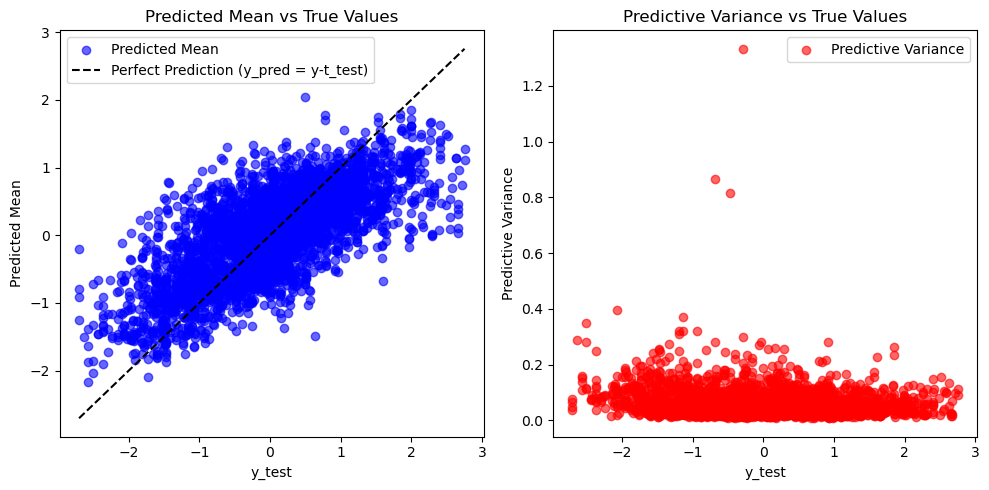

In [26]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, pred_mean, c='blue', label="Predicted Mean", alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', label="Perfect Prediction (y_pred = y-t_test)") 
plt.xlabel("y_test")
plt.ylabel("Predicted Mean")
plt.title("Predicted Mean vs True Values")
plt.legend()

# Plot 2: Predictive Variance (Uncertainty) vs True Values
plt.subplot(1, 2, 2)
plt.scatter(y_test, pred_variance, c='red', label="Predictive Variance", alpha=0.6)
plt.xlabel("y_test")
plt.ylabel("Predictive Variance")
plt.title("Predictive Variance vs True Values")
plt.legend()

plt.tight_layout()
plt.show()